# MVTec Anomaly Detection (AD) - Modular Dataset Exploration

## 1. Executive Summary

The **MVTec Anomaly Detection (MVTec AD)** benchmark is the de-facto standard dataset for evaluating unsupervised and one-class visual anomaly detection models in industrial quality inspection.

Key characteristics of the dataset include:
- **15 Diverse Categories:** Divided into 10 rigid/flexible object categories and 5 surface texture categories.
- **One-Class Protocol:** Training sets contain strictly defect-free (normal) images, mirroring industrial cold-start realities where defect samples are unavailable or unpredictable.
- **Evaluation Fidelity:** Test sets contain both normal items and a wide variety of defect types (scratches, cracks, contaminations, deformations) accompanied by pixel-accurate binary ground-truth masks.

All underlying data aggregation and plotting logic have been modularized into `src.data` and `src.utils`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Dynamically locate project root by locating data and src directories
current_path = Path.cwd().resolve()
PROJECT_ROOT = current_path
for p in [current_path, current_path.parent, current_path.parent.parent]:
    if (p / "src").exists() and (p / "data").exists():
        PROJECT_ROOT = p
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd

# Modular dataset extraction and inspection utilities from src
from src.data import (
    get_mvtec_summary,
    compute_defect_area_statistics,
    get_mvtec_dataloader,
    MVTecDataset,
    MVTEC_OBJECT_CATEGORIES,
    MVTEC_TEXTURE_CATEGORIES,
)
from src.utils import (
    plot_dataset_distribution,
    plot_defect_area_distribution,
    plot_multi_category_gallery,
    inspect_category,
)

print("PyTorch Version:", torch.__version__)
print("CUDA Available: ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:    ", torch.cuda.get_device_name(0))

DATA_DIR = PROJECT_ROOT / "data"
print("Data Directory: ", DATA_DIR.resolve())

PyTorch Version: 2.6.0+cu124
CUDA Available:  True
Device Name:     NVIDIA GeForce RTX 4050 Laptop GPU
Data Directory:  D:\HCMUT\Project\Anomaly Detection\data


## 2. Multi-Category Inventory & Taxonomy

We use `get_mvtec_summary` to aggregate sample distributions across all categories.
- **Objects (10 classes):** `bottle`, `cable`, `capsule`, `hazelnut`, `metal_nut`, `pill`, `screw`, `toothbrush`, `transistor`, `zipper`.
- **Textures (5 classes):** `carpet`, `grid`, `leather`, `tile`, `wood`.

In [2]:
df_summary = get_mvtec_summary(DATA_DIR)
display(df_summary[["Category", "Type", "Train Normal", "Test Normal", "Test Defect", "Test Total", "Total Images", "Defect Classes", "Test Anomaly Ratio (%)"]])

print("=" * 75)
print(f"Total Categories:           {len(df_summary)}")
print(f"Total Normal Train Images:  {df_summary['Train Normal'].sum():,}")
print(f"Total Test Images:          {df_summary['Test Total'].sum():,} ({df_summary['Test Normal'].sum():,} Normal + {df_summary['Test Defect'].sum():,} Anomaly)")
print(f"Grand Total Images:         {df_summary['Total Images'].sum():,}")
print("=" * 75)

,Category,Type,Train Normal,Test Normal,Test Defect,Test Total,Total Images,Defect Classes,Test Anomaly Ratio (%)
0,bottle,Object,209,20,63,83,292,3,75.9
1,cable,Object,224,58,92,150,374,8,61.3
2,capsule,Object,219,23,109,132,351,5,82.6
3,carpet,Texture,280,28,89,117,397,5,76.1
4,grid,Texture,264,21,57,78,342,5,73.1
5,hazelnut,Object,391,40,70,110,501,4,63.6
6,leather,Texture,245,32,92,124,369,5,74.2
7,metal_nut,Object,220,22,93,115,335,4,80.9
8,pill,Object,267,26,141,167,434,7,84.4
9,screw,Object,320,41,119,160,480,5,74.4


Total Categories:           15
Total Normal Train Images:  3,629
Total Test Images:          1,725 (467 Normal + 1,258 Anomaly)
Grand Total Images:         5,354


## 3. Visual Analytics: Sample Distribution & Defect Diversity

We call `plot_dataset_distribution` to render sample splits (Train Normal vs. Test Normal vs. Test Defect) and defect class counts.

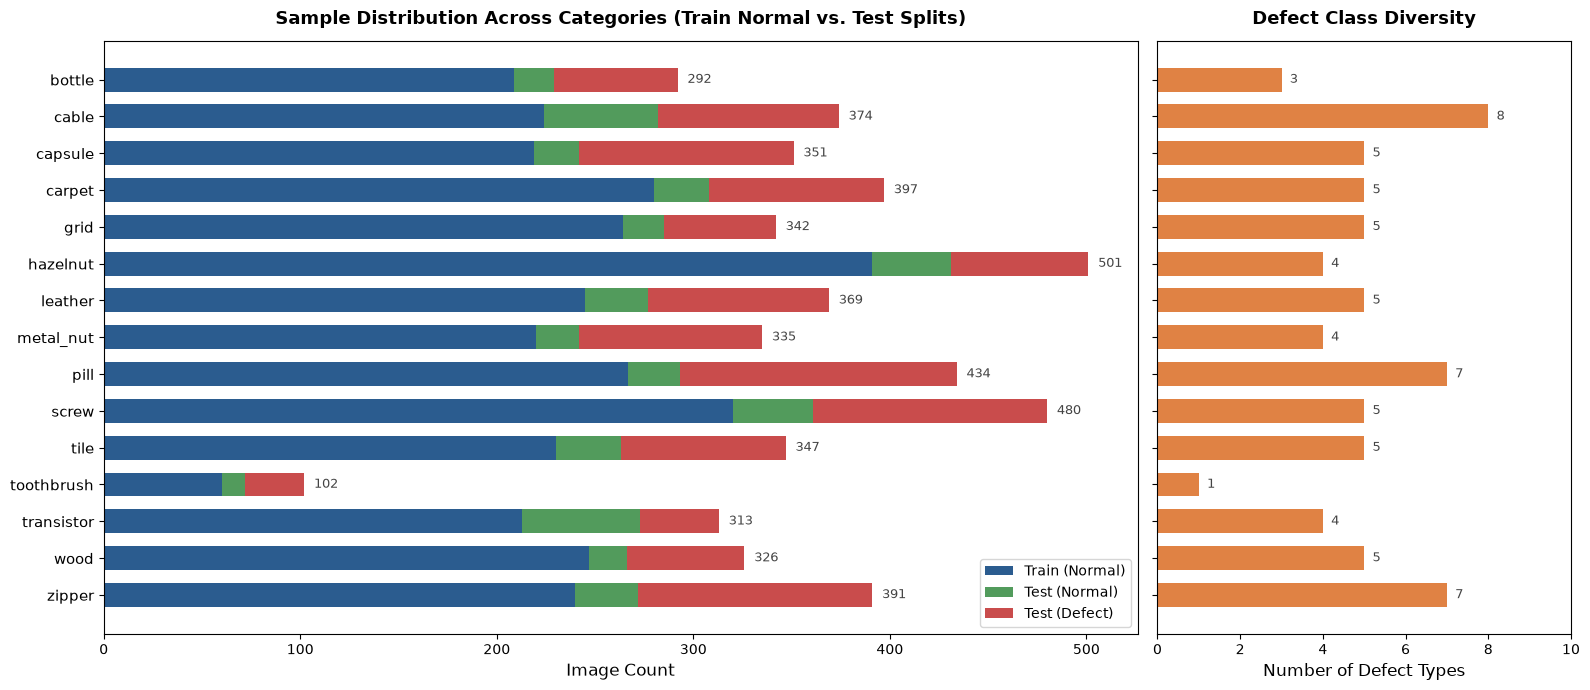

In [3]:
plot_dataset_distribution(df_summary)

## 4. Defect Morphometry: Analysis of Defect Size & Scale

Industrial defects range from microscopic pinholes to extensive fractures. We compute surface coverage ratios across all 1,258 ground-truth masks using `compute_defect_area_statistics`.

In [4]:
df_masks = compute_defect_area_statistics(DATA_DIR)

print(f"Total Defect Masks Evaluated:    {len(df_masks):,}")
print(f"Minimum Defect Coverage:         {df_masks['Area Ratio (%)'].min():.4f}%")
print(f"Median Defect Coverage:          {df_masks['Area Ratio (%)'].median():.2f}%")
print(f"Mean Defect Coverage:            {df_masks['Area Ratio (%)'].mean():.2f}%")
print(f"Maximum Defect Coverage:         {df_masks['Area Ratio (%)'].max():.2f}%")
print(f"Defects occupying < 1.0% Area:   {(df_masks['Area Ratio (%)'] < 1.0).mean() * 100:.1f}%")
print(f"Defects occupying < 0.2% Area:   {(df_masks['Area Ratio (%)'] < 0.2).mean() * 100:.1f}%")

Total Defect Masks Evaluated:    1,258
Minimum Defect Coverage:         0.0371%
Median Defect Coverage:          1.54%
Mean Defect Coverage:            4.39%
Maximum Defect Coverage:         49.32%
Defects occupying < 1.0% Area:   39.7%
Defects occupying < 0.2% Area:   6.3%


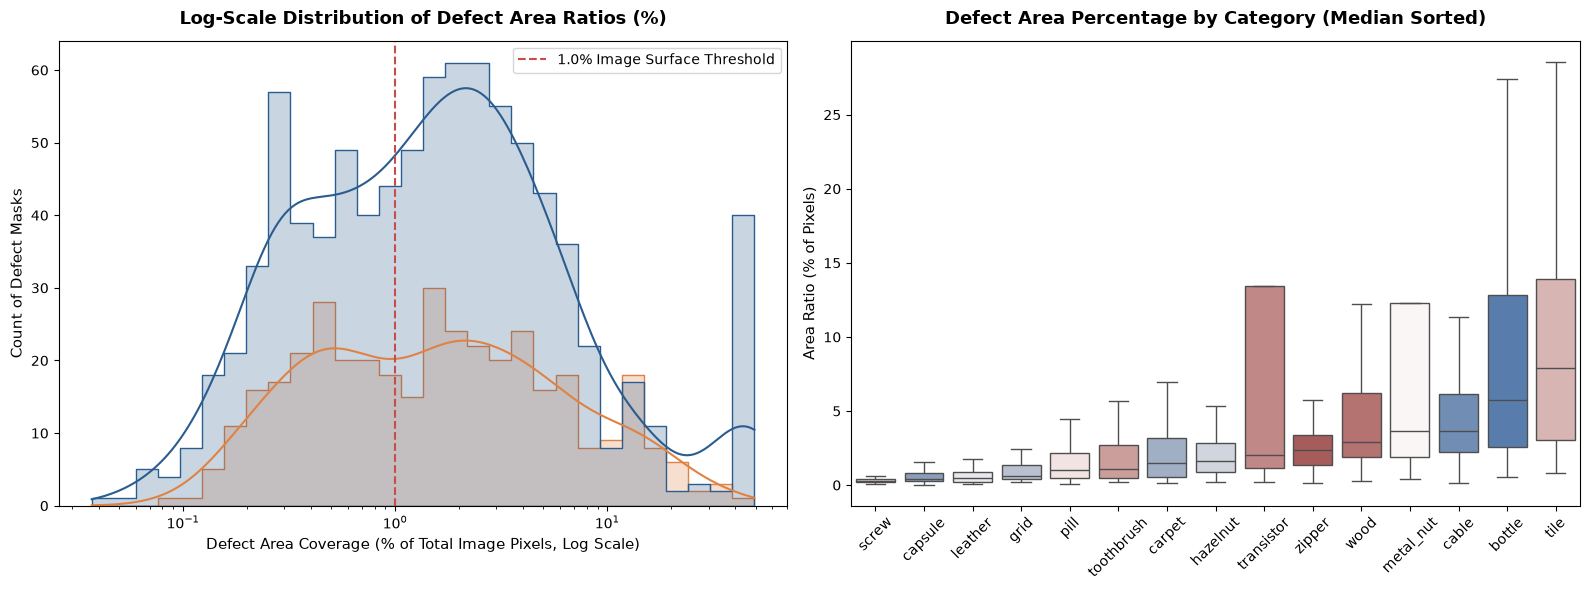

In [5]:
plot_defect_area_distribution(df_masks)

### Key Takeaway for Architecture Design:
> Nearly **40% of all defects occupy less than 1% of the image pixels**, and over **6% occupy less than 0.2%**.
>
> - **Reconstruction Models (Autoencoders):** When computing a global Mean Squared Error (MSE) loss, 99.8% normal pixels dominate the loss, making subtle scratches and small contaminations difficult to detect.
> - **Patch-Based Models (PatchCore):** By extracting and comparing local receptive-field patch features against a normal Memory Bank, local anomalies are detected at high sensitivity regardless of overall defect surface area.

## 5. Multi-Category Defect Gallery: Objects vs. Textures

We visualize representative defect samples across selected categories with `plot_multi_category_gallery`.

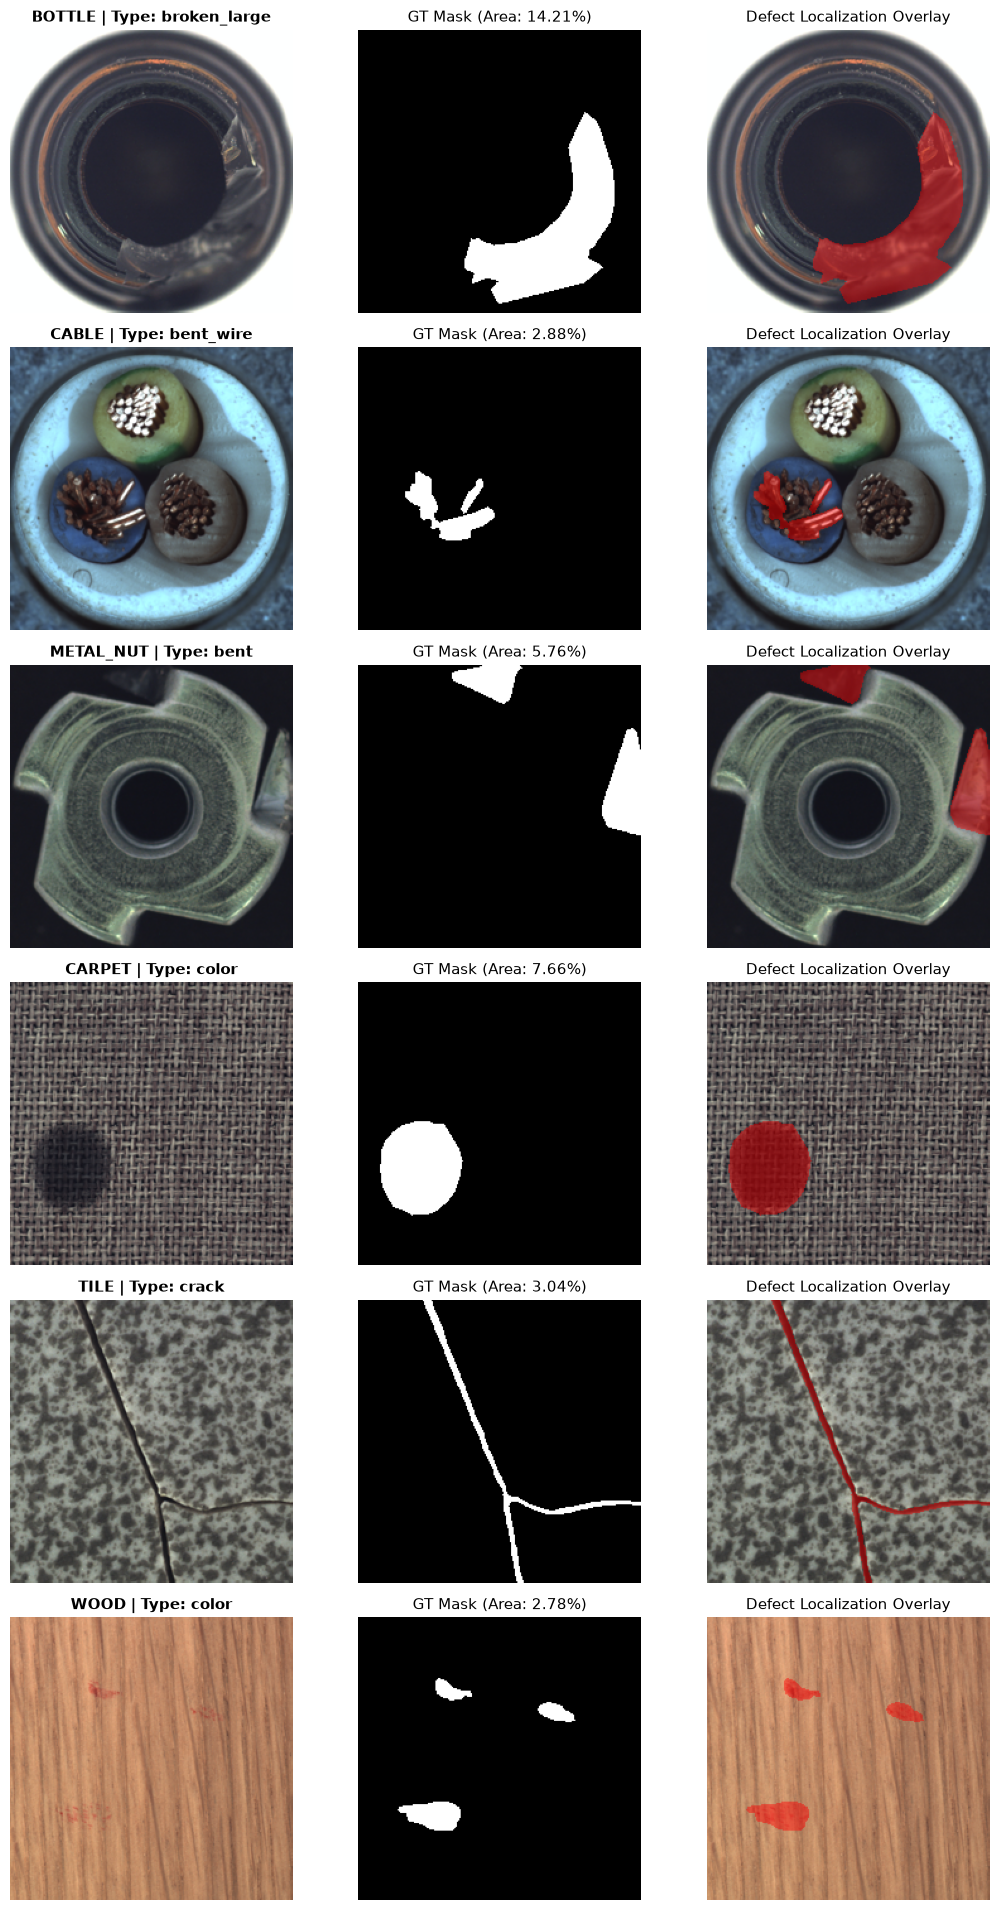

In [6]:
plot_multi_category_gallery(
    data_dir=DATA_DIR,
    categories=["bottle", "cable", "metal_nut", "carpet", "tile", "wood"]
)

## 6. Interactive Single-Category Explorer

Using `inspect_category`, we can examine all defect classes for any chosen category.

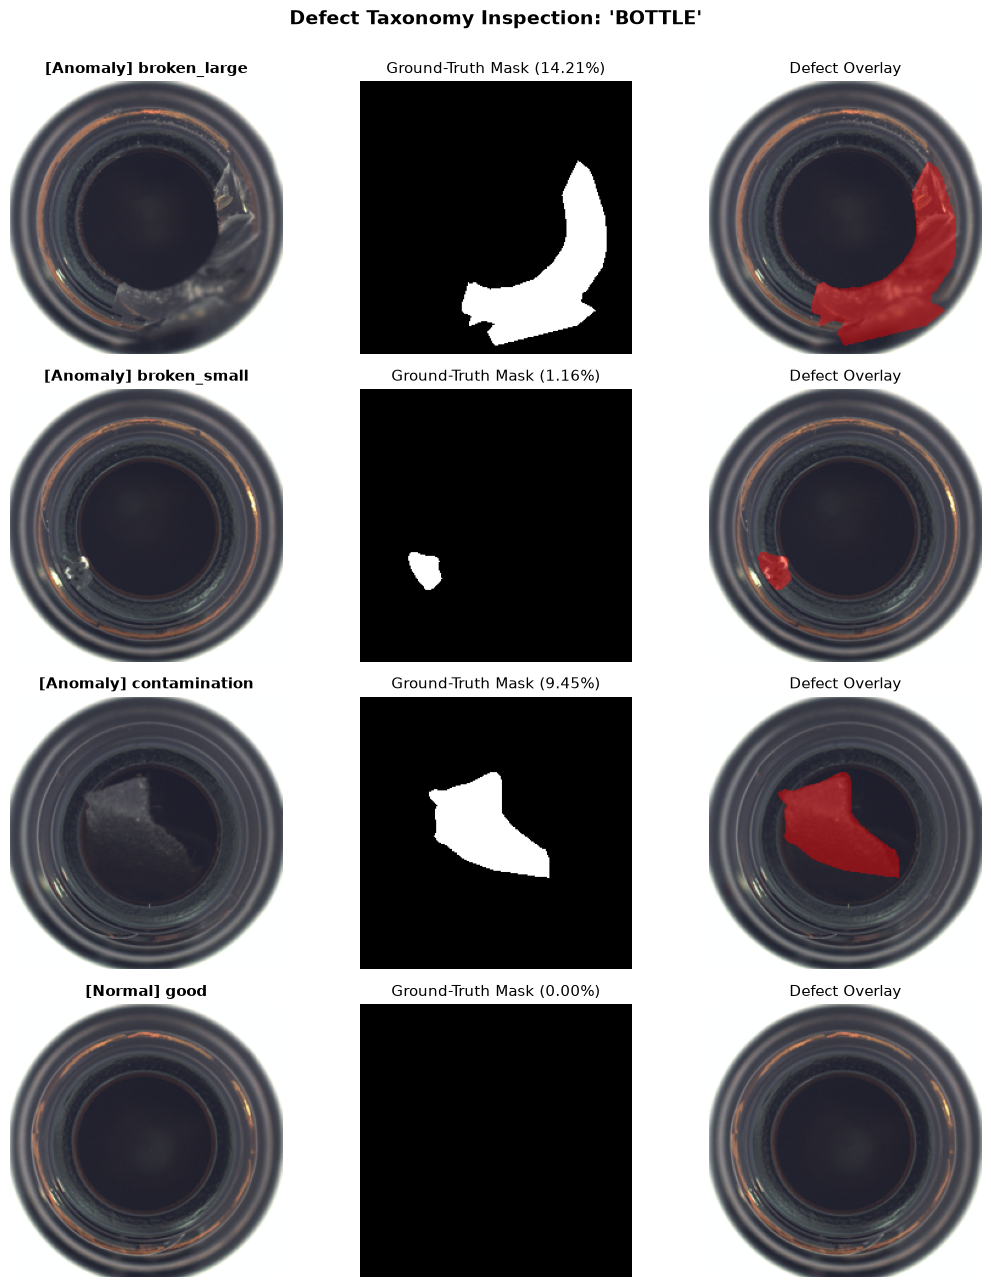

In [7]:
# Example 1: Object category (bottle)
inspect_category(data_dir=DATA_DIR, category_name="bottle")

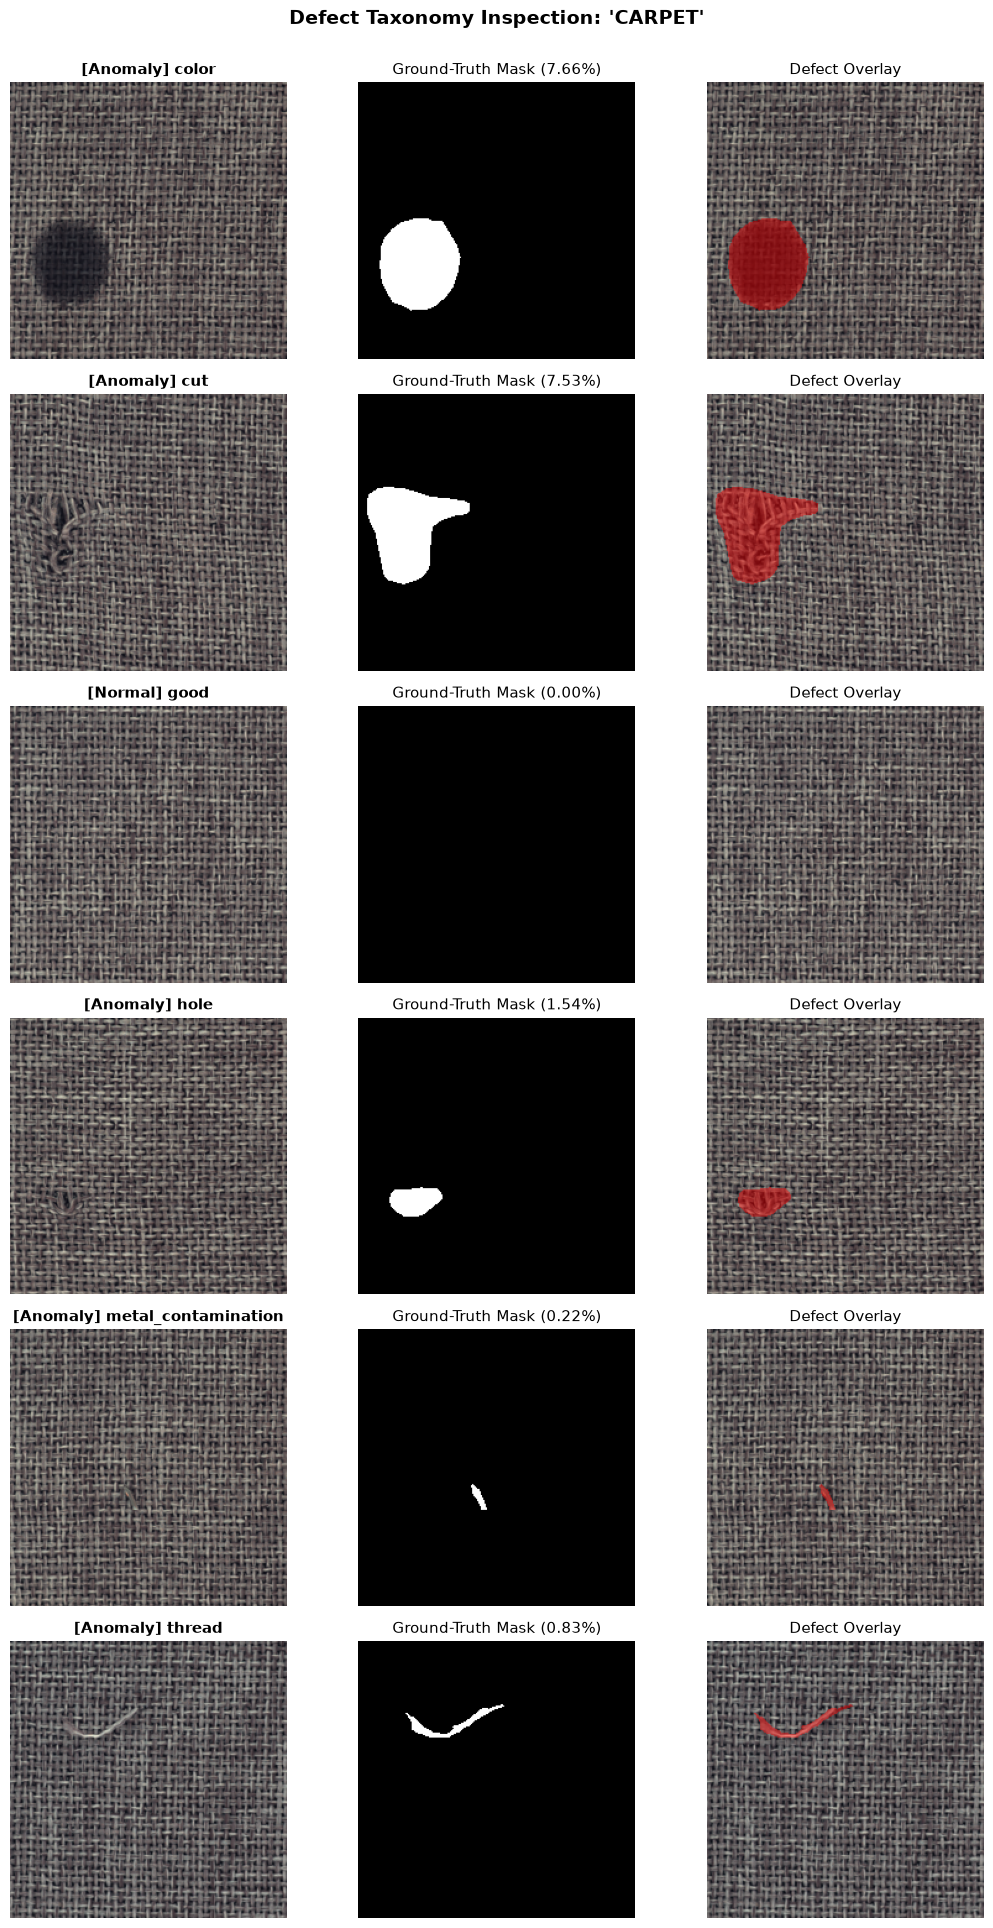

In [8]:
# Example 2: Texture category (carpet)
inspect_category(data_dir=DATA_DIR, category_name="carpet")

## 7. PyTorch DataLoader & Augmentation Verification

We verify that batches yielded by `get_mvtec_dataloader` have correct shapes, types, and value normalization ranges.

In [9]:
train_loader = get_mvtec_dataloader(
    root_dir=DATA_DIR,
    category="bottle",
    split="train",
    batch_size=8,
    shuffle=True,
    image_size=(256, 256),
    crop_size=(224, 224)
)

batch = next(iter(train_loader))

print("Train Batch Verification:")
print(f"  - Images Tensor Shape: {batch['image'].shape}  (dtype: {batch['image'].dtype})")
print(f"  - Masks Tensor Shape:  {batch['mask'].shape}   (dtype: {batch['mask'].dtype})")
print(f"  - Labels Tensor Shape: {batch['label'].shape}         (dtype: {batch['label'].dtype})")
print(f"  - Value Range (Images): [{batch['image'].min():.3f}, {batch['image'].max():.3f}]")
print(f"  - Value Range (Masks):  [{batch['mask'].min():.3f}, {batch['mask'].max():.3f}]")
print(f"  - Batch Labels:         {batch['label'].tolist()}  (0 = Normal)")

Train Batch Verification:
  - Images Tensor Shape: torch.Size([8, 3, 224, 224])  (dtype: torch.float32)
  - Masks Tensor Shape:  torch.Size([8, 1, 224, 224])   (dtype: torch.float32)
  - Labels Tensor Shape: torch.Size([8])         (dtype: torch.int64)
  - Value Range (Images): [-1.638, 2.640]
  - Value Range (Masks):  [0.000, 0.000]
  - Batch Labels:         [0, 0, 0, 0, 0, 0, 0, 0]  (0 = Normal)


### Critical Note on Data Augmentation in Anomaly Detection

In standard supervised classification or object detection (e.g., YOLO):
- Techniques like `Cutout`, `RandomErasing`, or strong `ColorJitter` are widely used to prevent overfitting.

In **One-Class Visual Anomaly Detection**:
- **`Cutout` / `RandomErasing` are prohibited during training:** Removing a square region artificially creates a defect on a normal image, corrupting the model's understanding of normality.
- **Rotations must respect physical constraints:** For upright products on an assembly line (e.g. `bottle`, `screw`), 180-degree rotations or excessive shearing deviate from the operational testing environment.
- **Safe Augmentations:** Subtle translation (shifts of a few pixels), minor scale adjustment, or very slight affine transformations (< 5 degrees).

## 8. Strategic Summary & Next Steps

### Summary of Findings
1. **Clean One-Class Split:** Training data is strictly normal (3,629 images). Testing data (1,725 images) evaluates both false-positive resistance (467 normal samples) and anomaly detection sensitivity (1,258 defect samples across 73 specific defect classes).
2. **Defect Morphometry:** Defect sizes vary from 0.04% to 49% of the image. The high concentration of sub-1% defects necessitates patch-level feature sensitivity for reliable localization.
3. **Domain Bifurcation:** The dataset provides equal opportunity to test models on structural geometry (Objects) and continuous repeating patterns (Textures).

### Proposed Next Steps (Step 2 - Convolutional Autoencoder Baseline)
1. **Architecture Implementation (`src/models/autoencoder.py`):**
   - Build a Convolutional Autoencoder comprising an encoder (progressive downsampling via `Conv2d` + `BatchNorm2d` + `LeakyReLU`) to a bottleneck latent representation, coupled with a symmetric decoder (`ConvTranspose2d` + `Sigmoid`).
2. **Training Pipeline:**
   - Train on defect-free samples using reconstruction loss ($L_1$ + SSIM / MSE) on CUDA GPU.
3. **Reconstruction Anomaly Scoring:**
   - Generate residual anomaly heatmaps: $\text{Anomaly Map} = |I - \hat{I}|$.
   - Benchmark initial Image-level AUROC.